In [9]:
import numpy as np
import matplotlib.pyplot as plt

1. Define lattice setup

In [10]:
L = 16  
num_species = 4
total_sites = L * L

2. Create an equal distribution of components and shuffle

In [ ]:
arrangement = np.repeat(np.arange(num_species), total_sites // num_species)

# simple probe
print(arrangement)

np.random.shuffle(arrangement)
lattice = arrangement.reshape((L, L))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


Plotting part

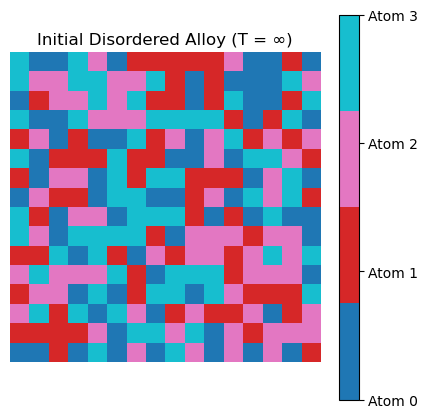

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))

# Modern way to grab a colormap and limit it to a discrete number of types
cmap_clean = plt.colormaps['tab10'].resampled(num_species)

im = ax.imshow(lattice, cmap=cmap_clean, vmin=0, vmax=num_species-1)

# Clean up the plot by removing axis tick marks
ax.axis('off')
ax.set_title("Initial Disordered Alloy (T = ∞)")

# Add a colorbar to show which color represents which atom type
cbar = plt.colorbar(im, ticks=range(num_species))
cbar.set_ticklabels(['Atom 0', 'Atom 1', 'Atom 2', 'Atom 3'])

plt.show()

Calculate the Total Energy

In [15]:
def calculate_total_energy(lattice, J=1.0):
    """
    Evaluates the Hamiltonian of the system.
    Sums up interaction energies across all unique nearest-neighbor bonds.
    """
    L = lattice.shape[0]
    print(L)
    total_energy = 0.0
    
    for i in range(L):
        for j in range(L):
            current_atom = lattice[i, j]
            
            # 1. Bond with Right Neighbor (with Periodic Boundary Conditions)
            neighbor_right = lattice[i, (j + 1) % L]
            if current_atom != neighbor_right:
                total_energy += J
                
            # 2. Bond with Down Neighbor (with Periodic Boundary Conditions)
            neighbor_down = lattice[(i + 1) % L, j]
            if current_atom != neighbor_down:
                total_energy += J
                
    return total_energy

# Test the function on your initialized lattice
initial_energy = calculate_total_energy(lattice, J=1.0)
print(f"Total Hamiltonian Energy of the initial random configuration: {initial_energy}")

16
Total Hamiltonian Energy of the initial random configuration: 389.0


Alternatively, with vectorization

In [ ]:
def calculate_total_energy_fast(lattice, J=1.0):
    """
    Calculates the total Hamiltonian energy using vectorized NumPy shifts.
    Eliminates all Python loops and conditional statements.
    """
    # np.roll(lattice, shift=-1, axis=1) shifts the entire grid to the left,
    # which effectively brings the 'Right' neighbor into alignment with the current site.
    right_neighbors = np.roll(lattice, shift=-1, axis=1)
    
    # np.roll(lattice, shift=-1, axis=0) shifts the grid up,
    # bringing the 'Down' neighbor into alignment.
    down_neighbors = np.roll(lattice, shift=-1, axis=0)
    
    # (lattice != right_neighbors) returns a boolean array (True where atoms mismatch)
    # np.sum() treats True as 1 and False as 0, counting all mismatch penalties at once.
    energy_right = np.sum(lattice != right_neighbors)
    energy_down = np.sum(lattice != down_neighbors)
    
    # Total energy is the sum of all mismatched right and down bonds
    return J * (energy_right + energy_down)

initial_energy = calculate_total_energy_fast(lattice, J=1.0)
print(initial_energy)

389.0


Half-realistic interaction matrix

In [18]:
# A symmetric 4x4 energy lookup matrix
energy_matrix = np.array([
    [ 0.0, -2.0,  0.5,  0.1],  # Interactions for Atom 0
    [-2.0,  0.0,  0.2,  0.8],  # Interactions for Atom 1
    [ 0.5,  0.2,  0.0,  1.5],  # Interactions for Atom 2
    [ 0.1,  0.8,  1.5,  0.0]   # Interactions for Atom 3
])

In [20]:
def calculate_matrix_energy_loops(lattice, energy_matrix):
    """
    Calculates total energy by manually looping through every site
    and looking up pair values in a symmetric interaction matrix.
    """
    L = lattice.shape[0]
    total_energy = 0.0
    
    # Loop over every row (i) and every column (j)
    for i in range(L):
        for j in range(L):
            # Identify the atom type at the current site (e.g., 0, 1, 2, or 3)
            current_atom = lattice[i, j]
            
            # 1. FIND THE RIGHT NEIGHBOR (with Periodic Boundary Conditions)
            neighbor_right_j = (j + 1) % L
            right_atom = lattice[i, neighbor_right_j]
            
            # Look up the energy penalty/reward for this specific pair
            bond_energy_right = energy_matrix[current_atom, right_atom]
            total_energy += bond_energy_right
            
            # 2. FIND THE DOWN NEIGHBOR (with Periodic Boundary Conditions)
            neighbor_down_i = (i + 1) % L
            down_atom = lattice[neighbor_down_i, j]
            
            # Look up the energy penalty/reward for this specific pair
            bond_energy_down = energy_matrix[current_atom, down_atom]
            total_energy += bond_energy_down
            
    return total_energy

initial_energy = calculate_matrix_energy_loops(lattice, energy_matrix)
print(initial_energy)

48.70000000000007


In [19]:
def calculate_matrix_energy(lattice, energy_matrix):
    """
    Calculates total energy where every atom pair configuration 
    has a specific energy defined in energy_matrix.
    """
    # Grab the right and down neighbors using our periodic wrapping
    right_neighbors = np.roll(lattice, shift=-1, axis=1)
    down_neighbors = np.roll(lattice, shift=-1, axis=0)
    
    # Advanced NumPy indexing:
    # energy_matrix[lattice, right_neighbors] creates a 2D array of the same shape
    # as our lattice, where each pixel contains the exact pair energy value.
    bonds_right = energy_matrix[lattice, right_neighbors]
    bonds_down = energy_matrix[lattice, down_neighbors]
    
    # Sum up all the mapped energies
    total_energy = np.sum(bonds_right) + np.sum(bonds_down)
    return total_energy

initial_energy = calculate_matrix_energy(lattice, energy_matrix)
print(initial_energy)

48.699999999999996
